In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

In [ ]:
File_Path = "/content/marketing_campaign .csv"
df = pd.read_csv(File_Path, sep='\t')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
# Check for missing values
print("Missing values before dropping:\n", df.isnull().sum())

# Drop rows with any NaN values
df.dropna(inplace=True)

# Check for missing values after dropping
print("\nMissing values after dropping:\n", df.isnull().sum())

# Check for redundant values (duplicates)
print("\nNumber of duplicate rows:", df.duplicated().sum())

# Describe the data
print("\nData Description:\n", df.describe())

Missing values before dropping:
 ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

Missing values after dropping:
 ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome         

In [ ]:
df['TotalSpend'] = df[['MntWines', 'MntFruits', 'MntMeatProducts',
                           'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum(axis=1)
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,TotalSpend
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,0,0,0,0,0,0,3,11,1,1617
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,0,0,0,0,0,0,3,11,0,27
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,0,0,0,0,0,0,3,11,0,776
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,0,0,0,0,0,0,3,11,0,53
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,0,0,0,0,0,0,3,11,0,422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,0,0,0,0,0,0,3,11,0,1341
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,0,0,0,1,0,0,3,11,0,444
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,0,1,0,0,0,0,3,11,0,1241
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,0,0,0,0,0,0,3,11,0,843


In [ ]:
from datetime import datetime
current_year = 2025
df['Age'] = current_year - df['Year_Birth']
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,TotalSpend,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,0,0,0,0,0,3,11,1,1617,68
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,0,0,0,0,0,3,11,0,27,71
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,0,0,0,0,0,3,11,0,776,60
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,0,0,0,0,0,3,11,0,53,41
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,0,0,0,0,0,3,11,0,422,44


In [ ]:
df['NumStorePurchases'].value_counts()

,count
NumStorePurchases,
3,484
4,319
2,220
5,211
6,177
8,147
7,141
10,124
9,106


In [ ]:
# Group similar marital statuses
marital_mapping = {
    'Single': 'Single',
    'Alone': 'Single',
    'YOLO': 'Single',
    'Absurd': 'Single',
    'Married': 'Married',
    'Together': 'Married',
    'Divorced': 'Divorced',
    'Widow': 'Divorced' # Assuming widow is closer to divorced for this analysis
}
df['Marital_Status'] = df['Marital_Status'].replace(marital_mapping)

# Verify the new categories
print(df['Marital_Status'].value_counts())

Marital_Status
Married     1430
Single       478
Divorced     308
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# Apply LabelEncoder to 'Education' column
df['Education'] = le.fit_transform(df['Education'])

# Apply LabelEncoder to 'Marital_Status' column
df['Marital_Status'] = le.fit_transform(df['Marital_Status'])

df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,TotalSpend,Age
0,5524,1957,2,2,58138.0,0,0,04-09-2012,58,635,...,0,0,0,0,0,3,11,1,1617,68
1,2174,1954,2,2,46344.0,1,1,08-03-2014,38,11,...,0,0,0,0,0,3,11,0,27,71
2,4141,1965,2,1,71613.0,0,0,21-08-2013,26,426,...,0,0,0,0,0,3,11,0,776,60
3,6182,1984,2,1,26646.0,1,0,10-02-2014,26,11,...,0,0,0,0,0,3,11,0,53,41
4,5324,1981,4,1,58293.0,1,0,19-01-2014,94,173,...,0,0,0,0,0,3,11,0,422,44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,2,1,61223.0,0,1,13-06-2013,46,709,...,0,0,0,0,0,3,11,0,1341,58
2236,4001,1946,4,1,64014.0,2,1,10-06-2014,56,406,...,0,0,1,0,0,3,11,0,444,79
2237,7270,1981,2,0,56981.0,0,0,25-01-2014,91,908,...,1,0,0,0,0,3,11,0,1241,44
2238,8235,1956,3,1,69245.0,0,1,24-01-2014,8,428,...,0,0,0,0,0,3,11,0,843,69


In [ ]:
features = df[['Income', 'Recency', 'Age','Education','Marital_Status','MntFruits','MntWines','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds','NumDealsPurchases','NumWebPurchases','NumCatalogPurchases','NumStorePurchases','NumWebVisitsMonth']]
scaler = StandardScaler()
X = scaler.fit_transform(features)

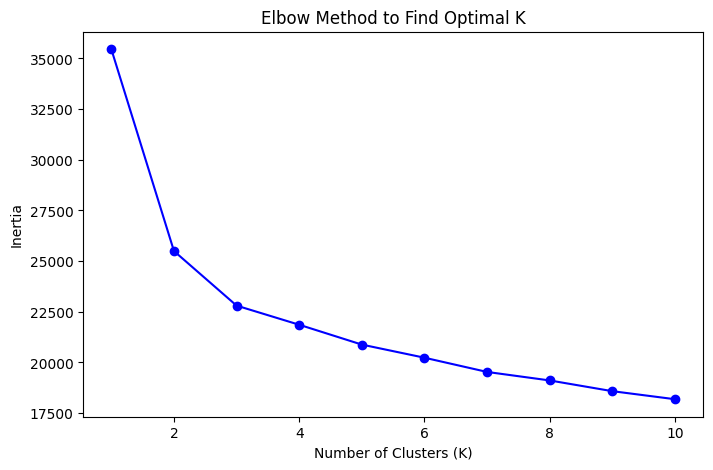

In [ ]:
# ✅ STEP 3: Determine Optimal K using Elbow Method
inertia = []
k_range = range(1, 11)
for k in k_range:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)
    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method to Find Optimal K')
plt.show()

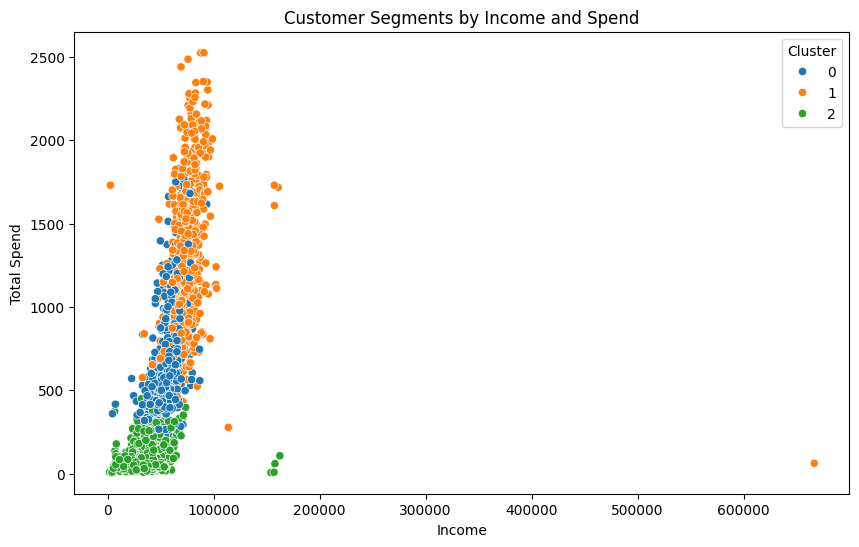

In [ ]:
# ✅ STEP 5: Fit KMeans with Chosen K (K=4)
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

# ✅ STEP 6: Analyze and Visualize Clusters
plt.figure(figsize=(10,6))
sns.scatterplot(x='Income', y='TotalSpend', hue='Cluster', data=df, palette='tab10')
plt.title('Customer Segments by Income and Spend')
plt.xlabel('Income')
plt.ylabel('Total Spend')
plt.show()


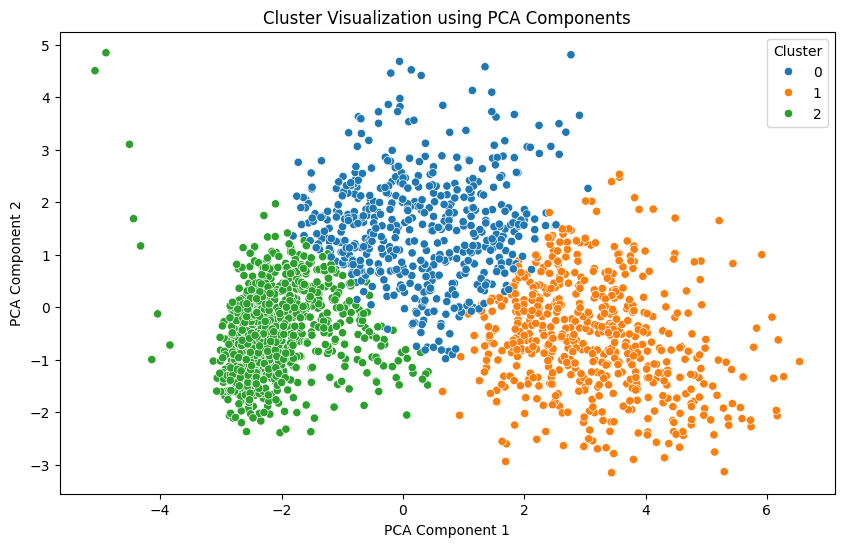

In [ ]:
from sklearn.decomposition import PCA

# Reduce to 2 dimensions for plotting
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X)

# Add PCA columns to dataframe
df['PCA1'] = pca_components[:, 0]
df['PCA2'] = pca_components[:, 1]

# Plot PCA-based cluster visualization
plt.figure(figsize=(10,6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='tab10')
plt.title('Cluster Visualization using PCA Components')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

In [ ]:
pca_df = pd.DataFrame(pca.components_, columns=features.columns, index=['PC1', 'PC2'])
pca_df

,Income,Recency,Age,Education,Marital_Status,MntFruits,MntWines,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
PC1,0.317286,0.007330,0.065699,0.018058,-0.011423,0.298750,0.316327,0.339059,0.308189,0.298257,0.244847,-0.040201,0.234572,0.343913,0.314144,-0.269698
PC2,0.041585,-0.007049,0.313908,0.314718,-0.192806,-0.183844,0.255835,-0.117291,-0.197586,-0.171344,0.083540,0.522837,0.427226,0.025978,0.176072,0.295837


In [ ]:
for k in [3, 4, 5]:
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f'Silhouette Score for K={k}: {score:.3f}')

Silhouette Score for K=3: 0.201
Silhouette Score for K=4: 0.106
Silhouette Score for K=5: 0.098


In [ ]:
print("\nCluster Sizes:")
print(df['Cluster'].value_counts())

print("\nDescriptive Stats for Each Cluster:")
print(df.groupby('Cluster')[features.columns].describe())


Cluster Sizes:
Cluster
2    1020
1     628
0     568
Name: count, dtype: int64

Descriptive Stats for Each Cluster:
         Income                                                         \
          count          mean           std     min       25%      50%   
Cluster                                                                  
0         568.0  56717.436620  11206.432329  4428.0  49810.75  57124.5   
1         628.0  76201.329618  26529.759837  2447.0  68731.00  75460.5   
2        1020.0  35009.774510  14570.554092  1730.0  25814.50  34508.0   

                            Recency             ... NumStorePurchases        \
              75%       max   count       mean  ...               75%   max   
Cluster                                         ...                           
0        64479.75   93404.0   568.0  47.184859  ...               9.0  13.0   
1        81807.00  666666.0   628.0  49.679936  ...              11.0  13.0   
2        42609.75  162397.0  1020.0  49.619

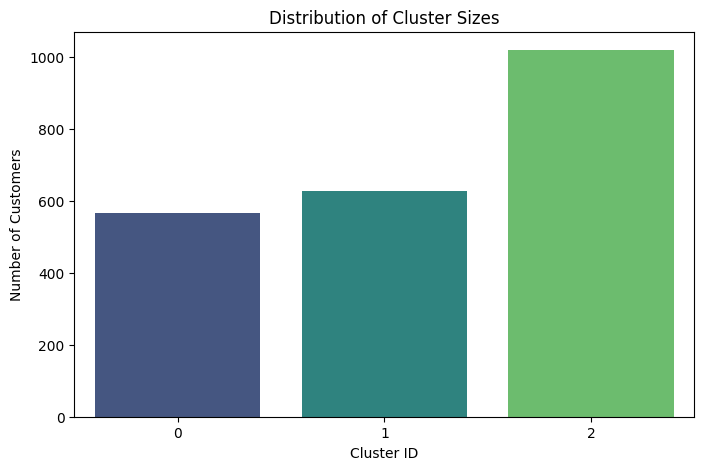

In [ ]:
import matplotlib.pyplot as plt
# Get the size of each cluster
cluster_sizes = df['Cluster'].value_counts().sort_index()

# Plot the distribution of cluster sizes
plt.figure(figsize=(8, 5))
sns.barplot(x=cluster_sizes.index, y=cluster_sizes.values, palette='viridis')
plt.title('Distribution of Cluster Sizes')
plt.xlabel('Cluster ID')
plt.ylabel('Number of Customers')
plt.show()


In [ ]:
# ✅ STEP 7: Cluster Profiling
cluster_profile = df.groupby('Cluster')[features.columns].mean().round(2)
print("\nCluster Profiles:")
print(cluster_profile)


Cluster Profiles:
           Income  Recency    Age  Education  Marital_Status  MntFruits  \
Cluster                                                                   
0        56717.44    47.18  60.21       2.76            0.99      17.46   
1        76201.33    49.68  56.91       2.32            1.10      68.59   
2        35009.77    49.62  53.48       2.24            1.11       5.30   

         MntWines  MntMeatProducts  MntFishProducts  MntSweetProducts  \
Cluster                                                                 
0          468.47           126.60            23.10             17.94   
1          588.65           438.43            99.01             70.46   
2           39.53            22.38             7.95              5.35   

         MntGoldProds  NumDealsPurchases  NumWebPurchases  \
Cluster                                                     
0               56.54               3.91             6.33   
1               79.12               1.49             5.3

In [ ]:
cluster_max = df.groupby('Cluster')[features.columns].max().round(2)
print("\n max values of clusters:")
print(cluster_max,"\n")

cluster_min = df.groupby('Cluster')[features.columns].min().round(2)
print("\n min values of clusters:")
print(cluster_min,"\n")


 max values of clusters:
           Income  Recency  Age  Education  Marital_Status  MntFruits  \
Cluster                                                                 
0         93404.0       99   82          4               2        138   
1        666666.0       99  126          4               2        199   
2        162397.0       99  132          4               2         87   

         MntWines  MntMeatProducts  MntFishProducts  MntSweetProducts  \
Cluster                                                                 
0            1462              514              223               157   
1            1493             1725              259               262   
2             279              153              179                78   

         MntGoldProds  NumDealsPurchases  NumWebPurchases  \
Cluster                                                     
0                 321                 15               25   
1                 249                 15               27  

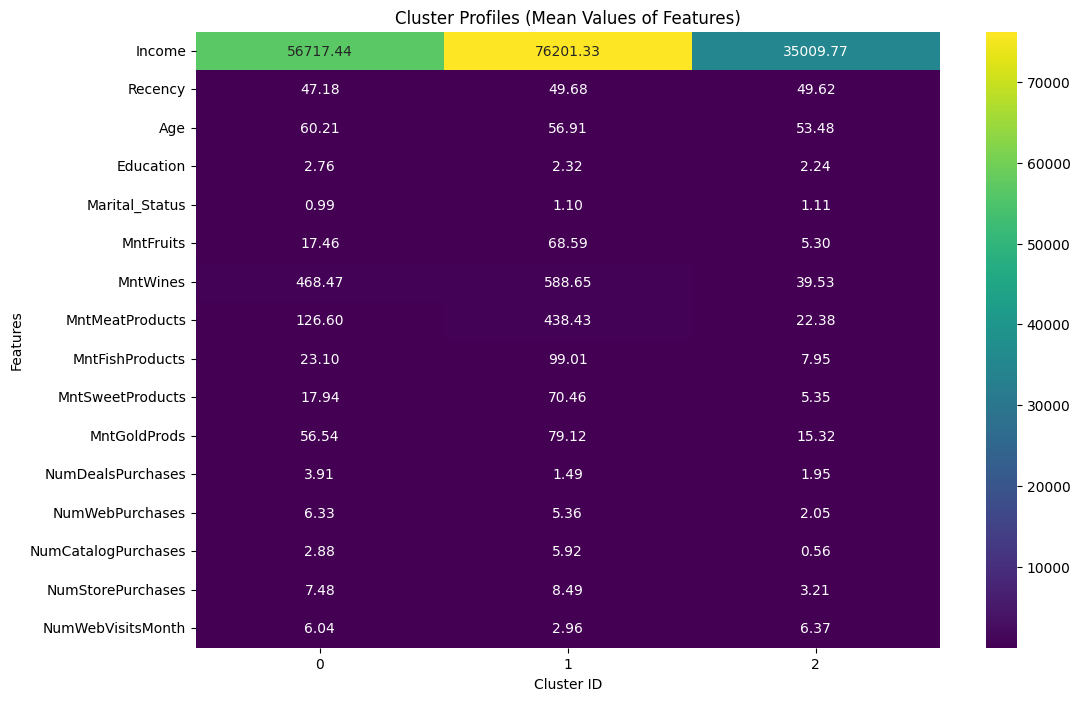

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(cluster_profile.T, annot=True, cmap='viridis', fmt=".2f")
plt.title('Cluster Profiles (Mean Values of Features)')
plt.xlabel('Cluster ID')
plt.ylabel('Features')
plt.yticks(rotation=0)
plt.show()


Maximum Values for Each Feature per Cluster:
           Income  Recency  Age  Education  Marital_Status  MntFruits  \
Cluster                                                                 
0         93404.0       99   82          4               2        138   
1        666666.0       99  126          4               2        199   
2        162397.0       99  132          4               2         87   

         MntWines  MntMeatProducts  MntFishProducts  MntSweetProducts  \
Cluster                                                                 
0            1462              514              223               157   
1            1493             1725              259               262   
2             279              153              179                78   

         MntGoldProds  NumDealsPurchases  NumWebPurchases  \
Cluster                                                     
0                 321                 15               25   
1                 249                 1

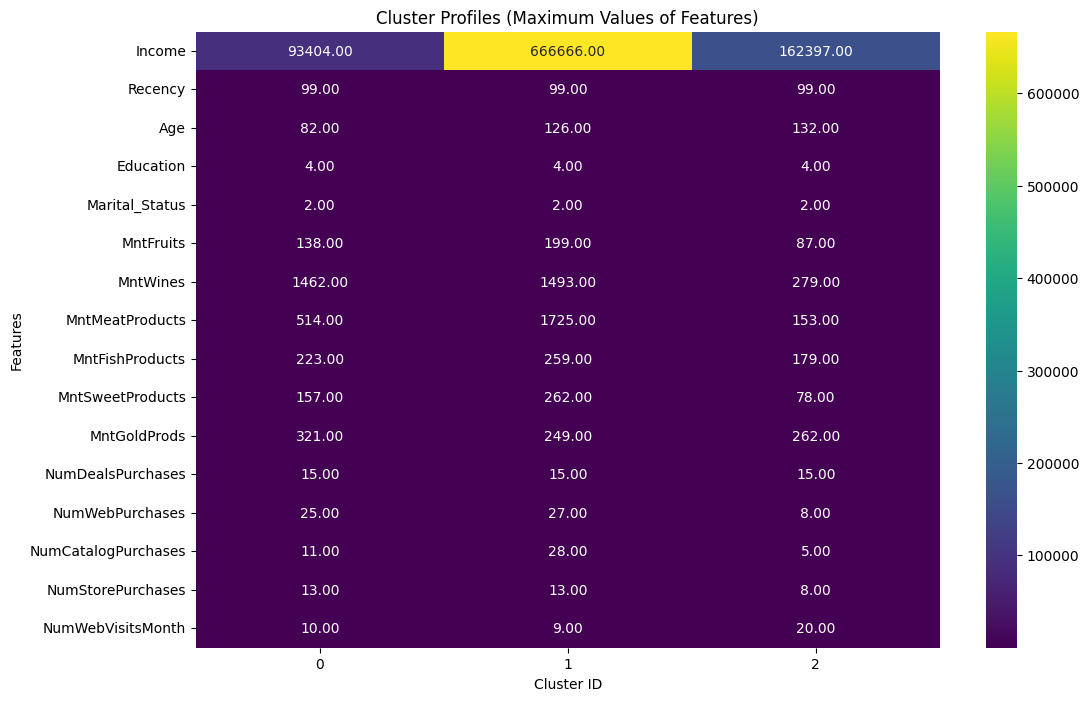

In [ ]:
# Calculate the maximum value for each feature within each cluster
cluster_max_values = df.groupby('Cluster')[features.columns].max().round(2)

# Print the maximum values
print("\nMaximum Values for Each Feature per Cluster:")
print(cluster_max_values)

# Visualize the maximum values using a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cluster_max_values.T, annot=True, cmap='viridis', fmt=".2f")
plt.title('Cluster Profiles (Maximum Values of Features)')
plt.xlabel('Cluster ID')
plt.ylabel('Features')
plt.yticks(rotation=0)
plt.show()